<a href="https://colab.research.google.com/github/snaval29/ML-Experiments/blob/main/experiment04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
#import all the required modeules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler


In [8]:
#Load Diabetes Dataset
data = load_diabetes()
X=pd.DataFrame(data.data,columns=data.feature_names)
y=pd.Series(data.target , name ="Disease_Progression")

df = pd.concat([X,y],axis=1)
print("Dataset Shape :",df.shape)

Dataset Shape : (442, 11)



Dataset Info :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  442 non-null    float64
 1   sex                  442 non-null    float64
 2   bmi                  442 non-null    float64
 3   bp                   442 non-null    float64
 4   s1                   442 non-null    float64
 5   s2                   442 non-null    float64
 6   s3                   442 non-null    float64
 7   s4                   442 non-null    float64
 8   s5                   442 non-null    float64
 9   s6                   442 non-null    float64
 10  Disease_Progression  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB
None

Statistical Summary :
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
m

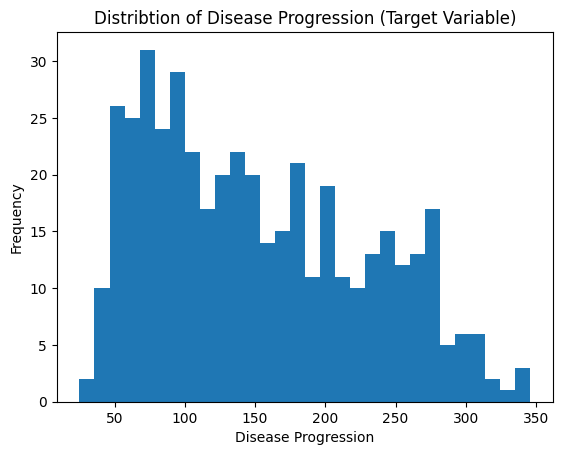

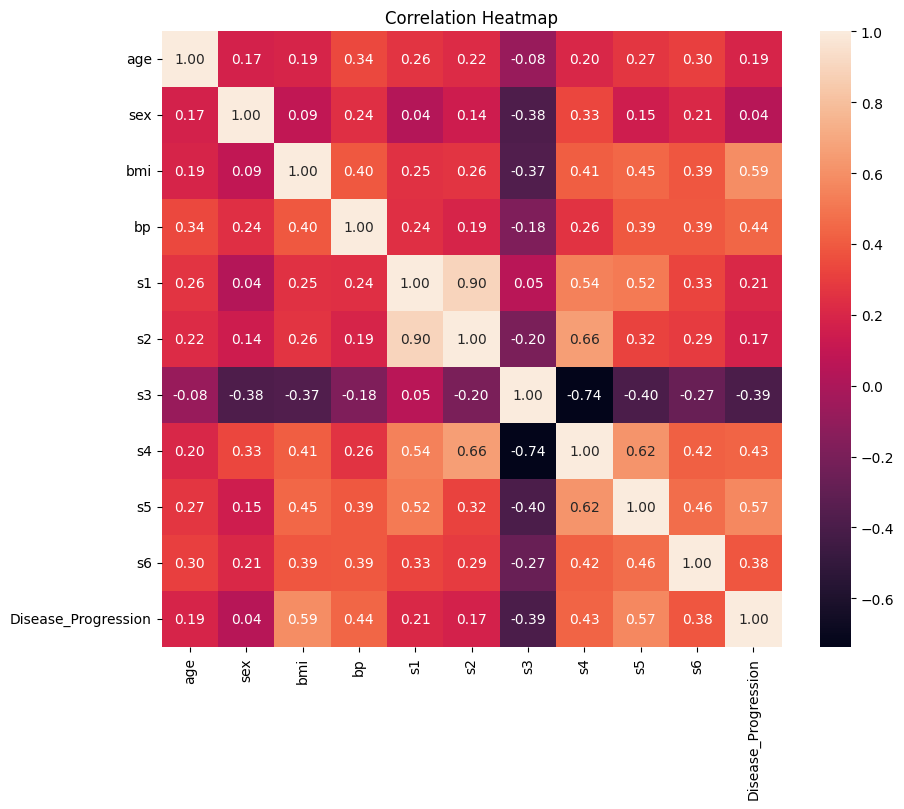

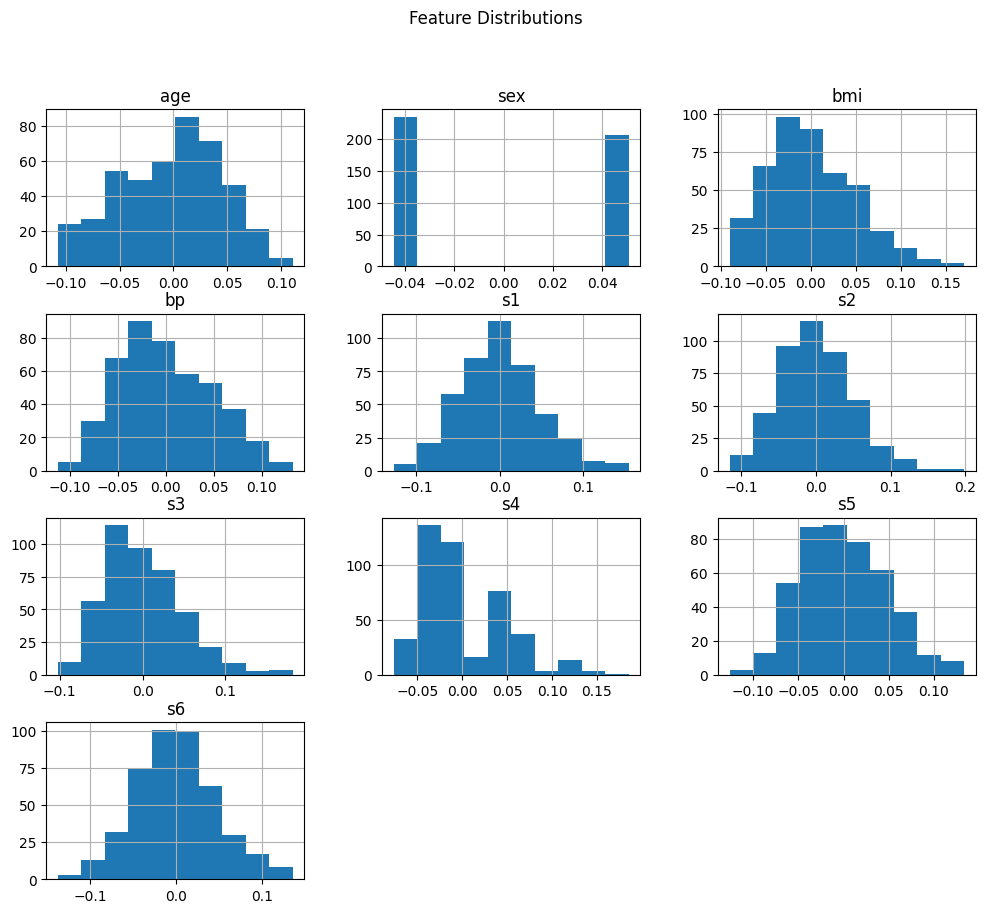

In [10]:
# Exploratory Data Analysis(EDA)
print("\nDataset Info :")
print(df.info())

print("\nStatistical Summary :")
print(df.describe())

#Check missing Values:
print("\nMissing Values :")
print(df.isnull().sum())

#Target Variable Distribution
plt.figure()
plt.hist(y, bins=30)
plt.title("Distribtion of Disease Progression (Target Variable)")
plt.xlabel("Disease Progression")
plt.ylabel("Frequency")
plt.show()

#Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt =".2f")
plt.title("Correlation Heatmap")
plt.show()

#feature distribution
df[X.columns].hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

#

In [13]:
#Feature Selection using Correlation Analysis
corr_matrix = X.corr().abs()

upper_triangle = corr_matrix.where( np.triu(np.ones(corr_matrix.shape),k=1).astype(np.bool_))
threshold = 0.90

to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)]

X_selected = X.drop(columns=to_drop)
print("Removed Features :", to_drop)
print("Selected Feature Shape:",X_selected.shape)

Removed Features : []
Selected Feature Shape: (442, 10)


In [19]:
#Features Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

In [16]:
#Model Selection
model = RandomForestRegressor(random_state = 42)

In [21]:
#Cross Validation (K-fold)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_score =cross_val_score(model, X_scaled, y, cv=kfold, scoring="r2")

print("/ncross Validation Scores :",cv_score)
print("Mean CV Score :",cv_score.mean())
print("Standard Deviation :",cv_score.std())

/ncross Validation Scores : [0.42687111 0.52943545 0.28398719 0.47681983 0.43225117]
Mean CV Score : 0.4298729503243696
Standard Deviation : 0.08174842152200484


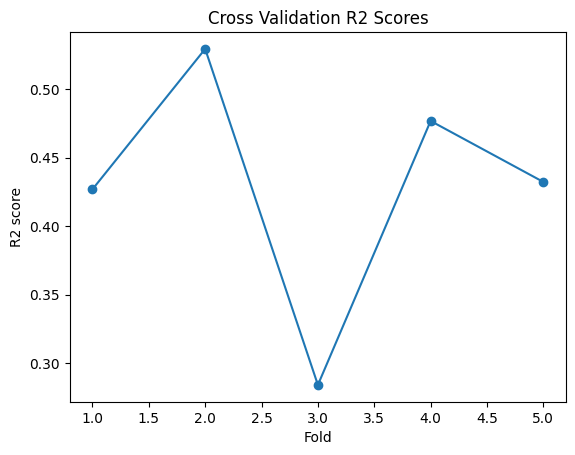

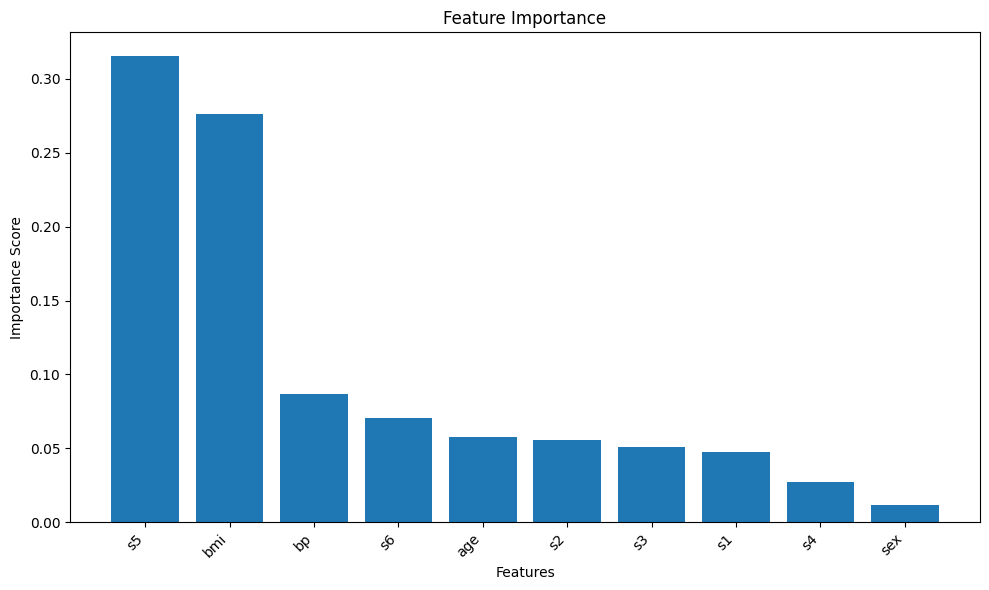

In [23]:
#Result Visualization
plt.figure()
plt.plot(range(1, len(cv_score) + 1), cv_score, marker='o')
plt.title("Cross Validation R2 Scores")
plt.xlabel("Fold")
plt.ylabel("R2 score")
plt.show()

#Feature importance Visualization
model.fit(X_scaled, y)
feature_importance = pd.Series(model.feature_importances_, index=X_selected.columns)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
plt.bar(feature_importance.index, feature_importance.values)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()